# Final Empathy Classifier

This notebook consolidates the project into one **final, clearly controlled pipeline**.

## Goal
Build the strongest classical empathy classifier found so far, using the best design choices from the previous notebooks.

## Fixed choices carried forward
- **Preprocessing:** the best preprocessing found earlier (minimal cleaning + lemmatization + **keep stopwords**)
- **Class imbalance handling:** **one technique only**, applied **only on the training split**  
  Here we use **random oversampling of the minority class**, because it is simple, transparent, easy to justify, and can be applied fairly to **both Logistic Regression and Naive Bayes**
- **Representation:** **TF-IDF up to trigrams**
- **Models:** **Logistic Regression** and **Naive Bayes**
- **Model selection:** hold-out validation with hyperparameter tuning
- **Evaluation focus:** macro-F1 and empathy recall/F1, not accuracy alone

## Why this notebook is organised this way
This notebook is no longer exploratory.  
It is the **final system notebook**:
1. load and clean the dataset
2. build robust splits
3. train tuned final models
4. compare models under the same setup
5. inspect the best model
6. optionally test lightweight conversational-structure features if metadata is available

## 1. Imports
We import the libraries used for:
- preprocessing
- vectorization
- train/validation/test splitting
- imbalance handling
- model tuning
- evaluation and plotting

In [1]:
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.sparse as sp

import nltk
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    ParameterGrid
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve
)

SEED = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

## 2. Download the NLTK resources used for lemmatization
The final preprocessing keeps stopwords, so we only need the lemmatizer resources.

In [2]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /Users/gjoli/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/gjoli/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 3. Load the dataset
The notebook looks for the dataset in common project locations.

In [4]:
df_raw = pd.read_csv("AcnEmpathize_dataset.csv")
print("Shape:", df_raw.shape)
print("Columns:")
print(list(df_raw.columns))

Shape: (12212, 13)
Columns:
['url', 'title', 'post_id', 'user_id', 'text', 'quoted_id', 'reputation_number', 'reviews_count', 'following_count', 'followers_count', 'forums_count', 'conv_id', 'combined_empathy']


## 4. Select the key columns

For the final pipeline we only need the following columns:
- the **text** column
- the **label** column
- the **conversation/thread** column (for conversation-level split)
- the **user** column (for user-level split)
- optional conversational metadata such as **post type** and **quoted id**

In [5]:
text_col = "text"
label_col = "combined_empathy"
conversation_col = "conv_id"
user_col = "user_id"
quoted_col = "quoted_id"

## 5. Keep the columns we need and standardise labels
We convert labels to binary form:
- `0` = no empathy
- `1` = empathy

This is a basic preparation step and is **not** one of the experimental variables.

In [ ]:
keep_cols = [text_col, label_col]
for c in [conversation_col, user_col, quoted_col]:
    if c is not None and c not in keep_cols:
        keep_cols.append(c)

df = df_raw[keep_cols].copy()
df = df.dropna(subset=[text_col, label_col]).copy()

label_map = {
    "no_empathy": 0,
    "empathy": 1
}
df[label_col] = df[label_col].map(lambda x: label_map.get(x, x))
df = df[df[label_col].isin([0, 1])].copy()

df[text_col] = df[text_col].astype(str)
df[label_col] = df[label_col].astype(int)

print("Filtered shape:", df.shape)
print("\nLabel distribution:")
print(df[label_col].value_counts(normalize=False))
print("\nLabel proportions:")
print(df[label_col].value_counts(normalize=True).round(4))

Filtered shape: (12212, 5)

Label distribution:
combined_empathy
0    9236
1    2976
Name: count, dtype: int64

Label proportions:
combined_empathy
0    0.7563
1    0.2437
Name: proportion, dtype: float64


## 6. Final preprocessing function
We use the best preprocessing found earlier:
- remove newlines
- lowercase
- strip accents
- remove punctuation/non-letters
- lemmatize
- **keep stopwords**

This keeps relational words such as *I*, *you*, and *we*, which were useful for empathy detection.

In [7]:
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    if not any(re.search(r"[a-z]", tok) for tok in tokens):
        return ""

    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(lemmas)

df["text_final"] = df[text_col].map(preprocess_text)
df = df[df["text_final"].str.len() > 0].copy()

print("Shape after preprocessing filter:", df.shape)
df[["text_final", label_col]].head()

Shape after preprocessing filter: (12212, 6)


,text_final,combined_empathy
0,hello i ve been having a hard time lingering a...,0
1,hey man the picture are not present can you po...,0
2,there are many many many many many many many d...,0
3,maybe in some african tribe my face scar would...,0
4,none of those opinion consider acne to be beau...,0


## 8. Final experimental configuration
We now define the final controlled setup.

### Text representation
We use **TF-IDF with word n-grams up to trigrams**, which was the strongest representation found earlier.

### Imbalance handling
We use **random oversampling on the training split only**.

Why this is a good final choice:
- simple and transparent
- avoids changing the validation/test distribution
- can be applied fairly to both Logistic Regression and Naive Bayes

### Threshold Optimization

Instead of using the default decision threshold (0.5), the code searches for the optimal threshold that maximizes a target metric (e.g., F1).

### Models
We compare:
- **Logistic Regression**
- **Naive Bayes**  
  We include both **MultinomialNB** and **ComplementNB**, then keep the better NB variant on validation.

In [ ]:
TFIDF_CONFIG = {
    "ngram_range": (1, 3),
    "max_features": 5000
}

LR_GRID = {
    "C": [0.01, 0.1, 1.0, 10.0]
}

MNB_GRID = {
    "alpha": [0.1, 0.5, 1.0, 2.0, 5.0]
}

THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.01), 2)
TARGET_METRIC_FOR_THRESHOLD = "macro_f1"   

## 9. Helper functions
This section collects the reusable functions used throughout the notebook:
- split construction
- class balancing
- metric computation
- threshold optimisation
- model training
- plotting

In [11]:
def summarize_labels(y, name="split"):
    counts = pd.Series(y).value_counts().sort_index()
    props = pd.Series(y).value_counts(normalize=True).sort_index().round(4)
    print(f"{name} counts:", counts.to_dict())
    print(f"{name} proportions:", props.to_dict())

def make_split_A(data, label_col, seed=SEED):
    train_val_idx, test_idx = train_test_split(
        data.index,
        test_size=0.20,
        random_state=seed,
        stratify=data[label_col]
    )

    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.20,   # 0.20 of 0.80 = 0.16 total
        random_state=seed,
        stratify=data.loc[train_val_idx, label_col]
    )

    return {
        "name": "Split A (post-level random)",
        "train_idx": np.array(train_idx),
        "val_idx": np.array(val_idx),
        "test_idx": np.array(test_idx),
        "type": "post"
    }

def make_group_split(data, label_col, group_col, split_name, seed=SEED):
    if group_col is None:
        return None

    groups = data[group_col].astype(str).fillna("missing_group")

    # first: train_val vs test
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    train_val_pos, test_pos = next(gss1.split(data, groups=groups))

    train_val_idx = data.iloc[train_val_pos].index
    test_idx = data.iloc[test_pos].index

    # second: train vs val within remaining groups
    groups_train_val = groups.loc[train_val_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    train_pos_rel, val_pos_rel = next(gss2.split(data.loc[train_val_idx], groups=groups_train_val))

    train_idx = data.loc[train_val_idx].iloc[train_pos_rel].index
    val_idx = data.loc[train_val_idx].iloc[val_pos_rel].index

    return {
        "name": split_name,
        "train_idx": np.array(train_idx),
        "val_idx": np.array(val_idx),
        "test_idx": np.array(test_idx),
        "type": "group",
        "group_col": group_col
    }

def random_oversample(X, y, seed=SEED):
    rng = np.random.RandomState(seed)
    y = np.asarray(y)

    classes, counts = np.unique(y, return_counts=True)
    max_count = counts.max()

    sampled_indices = []
    for cls, count in zip(classes, counts):
        cls_idx = np.where(y == cls)[0]
        if count < max_count:
            extra = rng.choice(cls_idx, size=max_count - count, replace=True)
            cls_idx = np.concatenate([cls_idx, extra])
        sampled_indices.append(cls_idx)

    sampled_indices = np.concatenate(sampled_indices)
    rng.shuffle(sampled_indices)

    if sp.issparse(X):
        X_res = X[sampled_indices]
    else:
        X_res = np.asarray(X)[sampled_indices]

    y_res = y[sampled_indices]
    return X_res, y_res

def compute_metrics(y_true, y_pred, y_score=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    row = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "precision_empathy": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_empathy": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_empathy": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_no_empathy": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_no_empathy": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_no_empathy": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
    }
    if y_score is not None:
        row["auprc"] = average_precision_score(y_true, y_score)
    else:
        row["auprc"] = np.nan
    return row

def evaluate_at_threshold(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    return compute_metrics(y_true, y_pred, y_score=y_score)

def search_best_threshold(y_true, y_score, objective=TARGET_METRIC_FOR_THRESHOLD, thresholds=THRESHOLDS):
    rows = []
    for thr in thresholds:
        m = evaluate_at_threshold(y_true, y_score, thr)
        m["threshold"] = thr
        rows.append(m)
    grid = pd.DataFrame(rows).sort_values(objective, ascending=False).reset_index(drop=True)
    best = grid.iloc[0].to_dict()
    return best, grid

def evaluate_predictions(name, split_name, y_true, y_score, threshold, extra=None):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    row = {"experiment": name, "split": split_name, "threshold": threshold}
    row.update(compute_metrics(y_true, y_pred, y_score=y_score))
    if extra:
        row.update(extra)
    return row, y_pred

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=["true_no_empathy", "true_empathy"],
        columns=["pred_no_empathy", "pred_empathy"]
    )
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_pr_curve(y_true, y_score, title):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def top_lr_features(vectorizer, clf, top_n=20):
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = clf.coef_.ravel()
    top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
    top_neg_idx = np.argsort(coefs)[:top_n]

    pos_df = pd.DataFrame({
        "feature": feature_names[top_pos_idx],
        "weight": coefs[top_pos_idx]
    })

    neg_df = pd.DataFrame({
        "feature": feature_names[top_neg_idx],
        "weight": coefs[top_neg_idx]
    })

    return pos_df, neg_df

## 10. Model-fitting helpers
We tune:
- **Logistic Regression** over `C`
- **Naive Bayes** over `alpha`

For each model:
1. fit on the oversampled training set
2. predict probabilities on validation
3. choose the threshold that maximises the selected validation objective
4. keep the best configuration

In [12]:
def fit_best_logreg(Xtr, ytr, Xva, yva):
    history = []
    best_model = None
    best_score = -1
    best_params = None
    best_threshold = 0.5
    best_threshold_grid = None

    for params in ParameterGrid(LR_GRID):
        clf = LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=SEED,
            **params
        )
        clf.fit(Xtr, ytr)
        val_score = clf.predict_proba(Xva)[:, 1]
        best_thr_info, thr_grid = search_best_threshold(yva, val_score)

        row = {
            "model_family": "LogisticRegression",
            "C": params["C"],
            "best_threshold": best_thr_info["threshold"],
            "val_macro_f1": best_thr_info["macro_f1"],
            "val_f1_empathy": best_thr_info["f1_empathy"],
            "val_recall_empathy": best_thr_info["recall_empathy"],
            "val_auprc": best_thr_info["auprc"]
        }
        history.append(row)

        if best_thr_info[TARGET_METRIC_FOR_THRESHOLD] > best_score:
            best_score = best_thr_info[TARGET_METRIC_FOR_THRESHOLD]
            best_model = clf
            best_params = params
            best_threshold = best_thr_info["threshold"]
            best_threshold_grid = thr_grid

    history_df = pd.DataFrame(history).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
    return best_model, best_params, best_threshold, history_df, best_threshold_grid

def fit_best_nb(Xtr, ytr, Xva, yva):
    history = []
    best_model = None
    best_score = -1
    best_params = None
    best_threshold = 0.5
    best_threshold_grid = None

    for nb_name, nb_cls in [("MultinomialNB", MultinomialNB), ("ComplementNB", ComplementNB)]:
        for params in ParameterGrid(MNB_GRID):
            clf = nb_cls(**params)
            clf.fit(Xtr, ytr)
            val_score = clf.predict_proba(Xva)[:, 1]
            best_thr_info, thr_grid = search_best_threshold(yva, val_score)

            row = {
                "model_family": nb_name,
                "alpha": params["alpha"],
                "best_threshold": best_thr_info["threshold"],
                "val_macro_f1": best_thr_info["macro_f1"],
                "val_f1_empathy": best_thr_info["f1_empathy"],
                "val_recall_empathy": best_thr_info["recall_empathy"],
                "val_auprc": best_thr_info["auprc"]
            }
            history.append(row)

            if best_thr_info[TARGET_METRIC_FOR_THRESHOLD] > best_score:
                best_score = best_thr_info[TARGET_METRIC_FOR_THRESHOLD]
                best_model = clf
                best_params = {"nb_variant": nb_name, **params}
                best_threshold = best_thr_info["threshold"]
                best_threshold_grid = thr_grid

    history_df = pd.DataFrame(history).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
    return best_model, best_params, best_threshold, history_df, best_threshold_grid

## 11. Main experiment runner
This function runs the full final pipeline for one split:
1. build train/validation/test subsets
2. fit TF-IDF on training text only
3. oversample the training features
4. tune Logistic Regression and Naive Bayes
5. evaluate on validation and test

In [13]:
def run_text_only_experiment(data, split_info, text_feature_col="text_final", label_col=label_col):
    train_df = data.loc[split_info["train_idx"]].copy()
    val_df = data.loc[split_info["val_idx"]].copy()
    test_df = data.loc[split_info["test_idx"]].copy()

    print(split_info["name"])
    summarize_labels(train_df[label_col], "train")
    summarize_labels(val_df[label_col], "val")
    summarize_labels(test_df[label_col], "test")
    print("-" * 80)

    vectorizer = TfidfVectorizer(**TFIDF_CONFIG)

    Xtr = vectorizer.fit_transform(train_df[text_feature_col])
    Xva = vectorizer.transform(val_df[text_feature_col])
    Xte = vectorizer.transform(test_df[text_feature_col])

    ytr = train_df[label_col].values
    yva = val_df[label_col].values
    yte = test_df[label_col].values

    # balance only the training split
    Xtr_bal, ytr_bal = random_oversample(Xtr, ytr, seed=SEED)

    results = []
    artifacts = {}

    # Logistic Regression
    lr_clf, lr_params, lr_thr, lr_hist, lr_thr_grid = fit_best_logreg(Xtr_bal, ytr_bal, Xva, yva)
    lr_val_score = lr_clf.predict_proba(Xva)[:, 1]
    lr_test_score = lr_clf.predict_proba(Xte)[:, 1]

    lr_val_row, lr_val_pred = evaluate_predictions(
        "Logistic Regression", "validation", yva, lr_val_score, lr_thr,
        extra={"split_name": split_info["name"], **lr_params}
    )
    lr_test_row, lr_test_pred = evaluate_predictions(
        "Logistic Regression", "test", yte, lr_test_score, lr_thr,
        extra={"split_name": split_info["name"], **lr_params}
    )

    results.extend([lr_val_row, lr_test_row])
    artifacts["lr"] = {
        "model": lr_clf,
        "params": lr_params,
        "threshold": lr_thr,
        "history": lr_hist,
        "threshold_grid": lr_thr_grid,
        "val_pred": lr_val_pred,
        "test_pred": lr_test_pred,
        "val_score": lr_val_score,
        "test_score": lr_test_score
    }

    # Naive Bayes
    nb_clf, nb_params, nb_thr, nb_hist, nb_thr_grid = fit_best_nb(Xtr_bal, ytr_bal, Xva, yva)
    nb_val_score = nb_clf.predict_proba(Xva)[:, 1]
    nb_test_score = nb_clf.predict_proba(Xte)[:, 1]

    nb_val_row, nb_val_pred = evaluate_predictions(
        "Naive Bayes", "validation", yva, nb_val_score, nb_thr,
        extra={"split_name": split_info["name"], **nb_params}
    )
    nb_test_row, nb_test_pred = evaluate_predictions(
        "Naive Bayes", "test", yte, nb_test_score, nb_thr,
        extra={"split_name": split_info["name"], **nb_params}
    )

    results.extend([nb_val_row, nb_test_row])
    artifacts["nb"] = {
        "model": nb_clf,
        "params": nb_params,
        "threshold": nb_thr,
        "history": nb_hist,
        "threshold_grid": nb_thr_grid,
        "val_pred": nb_val_pred,
        "test_pred": nb_test_pred,
        "val_score": nb_val_score,
        "test_score": nb_test_score
    }

    artifacts["vectorizer"] = vectorizer
    artifacts["split"] = split_info
    artifacts["data_subsets"] = {
        "train": train_df,
        "val": val_df,
        "test": test_df
    }

    results_df = pd.DataFrame(results)
    return results_df, artifacts

## 12. Build the evaluation splits
We prepare:


- Split A – Reproduction of the paper (post-level random 80/20).
Used to directly compare with the baseline numbers.

- Split B – Conversation-level split.
    - Reason: posts within the same conversation share topics, names, styles, and even repeated phrases; if part of the conversation is in training and part in testing, the test becomes artificially easy. The dataset itself includes conversation IDs and quoted_id, so applying this split is natural.

- Split C – User-level split (optional but very strong).
    - Reason: there are “super users” (the paper reports users with ≥100 posts) and user metadata; a user-level split tests whether the model detects empathy as a linguistic phenomenon rather than author “signatures.”


In [25]:
split_A = make_split_A(df, label_col=label_col, seed=SEED)
split_B = make_group_split(df, label_col=label_col, group_col=conversation_col,
                           split_name="Split B (conversation-level)", seed=SEED)
split_C = make_group_split(df, label_col=label_col, group_col=user_col,
                           split_name="Split C (user-level)", seed=SEED)

available_splits = [s for s in [split_A, split_B, split_C] if s is not None]

print("Available splits:")
for s in available_splits:
    print("-", s["name"])

Available splits:
- Split A (post-level random)
- Split B (conversation-level)
- Split C (user-level)


## 13. Run the final text-only pipeline on all available splits
This is the core final experiment.

In [15]:
all_results = []
all_artifacts = {}

for split_info in available_splits:
    results_df, artifacts = run_text_only_experiment(df, split_info)
    all_results.append(results_df)
    all_artifacts[split_info["name"]] = artifacts

final_results_df = pd.concat(all_results, ignore_index=True)
final_results_df

Split A (post-level random)
train counts: {0: 5910, 1: 1905}
train proportions: {0: 0.7562, 1: 0.2438}
val counts: {0: 1478, 1: 476}
val proportions: {0: 0.7564, 1: 0.2436}
test counts: {0: 1848, 1: 595}
test proportions: {0: 0.7564, 1: 0.2436}
--------------------------------------------------------------------------------
Split B (conversation-level)
train counts: {0: 5780, 1: 1945}
train proportions: {0: 0.7482, 1: 0.2518}
val counts: {0: 1497, 1: 491}
val proportions: {0: 0.753, 1: 0.247}
test counts: {0: 1959, 1: 540}
test proportions: {0: 0.7839, 1: 0.2161}
--------------------------------------------------------------------------------
Split C (user-level)
train counts: {0: 6052, 1: 2005}
train proportions: {0: 0.7511, 1: 0.2489}
val counts: {0: 1564, 1: 451}
val proportions: {0: 0.7762, 1: 0.2238}
test counts: {0: 1620, 1: 520}
test proportions: {0: 0.757, 1: 0.243}
--------------------------------------------------------------------------------


,experiment,split,threshold,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,auprc,split_name,C,nb_variant,alpha
0,Logistic Regression,validation,0.63,0.851075,0.786090,0.730673,0.615546,0.668187,0.882164,0.926928,0.903992,0.734735,Split A (post-level random),1.0,NaN,NaN
1,Logistic Regression,test,0.63,0.846500,0.777567,0.725410,0.594958,0.653740,0.876726,0.927489,0.901394,0.750160,Split A (post-level random),1.0,NaN,NaN
2,Naive Bayes,validation,0.60,0.814739,0.738308,0.635071,0.563025,0.596882,0.864230,0.895805,0.879734,0.660715,Split A (post-level random),NaN,MultinomialNB,5.0
3,Naive Bayes,test,0.60,0.803111,0.724665,0.604779,0.552941,0.577700,0.859926,0.883658,0.871631,0.644687,Split A (post-level random),NaN,MultinomialNB,5.0
4,Logistic Regression,validation,0.51,0.824950,0.777244,0.623917,0.733198,0.674157,0.907158,0.855043,0.880330,0.721006,Split B (conversation-level),1.0,NaN,NaN
5,Logistic Regression,test,0.51,0.824330,0.760514,0.575486,0.712963,0.636890,0.915301,0.855028,0.884138,0.722632,Split B (conversation-level),1.0,NaN,NaN
6,Naive Bayes,validation,0.61,0.813380,0.737069,0.640845,0.556008,0.595420,0.860435,0.897796,0.878719,0.653164,Split B (conversation-level),NaN,MultinomialNB,5.0
7,Naive Bayes,test,0.61,0.826731,0.730758,0.614561,0.531481,0.570010,0.875492,0.908116,0.891506,0.631365,Split B (conversation-level),NaN,MultinomialNB,5.0
8,Logistic Regression,validation,0.55,0.849132,0.782549,0.663697,0.660754,0.662222,0.902299,0.903453,0.902875,0.725951,Split C (user-level),1.0,NaN,NaN
9,Logistic Regression,test,0.55,0.834112,0.778123,0.651376,0.682692,0.666667,0.896552,0.882716,0.889580,0.722147,Split C (user-level),1.0,NaN,NaN


## 14. Focus on the test results
Validation is used for tuning.  
We make the final comparison on the **test rows only**.

In [16]:
test_results = final_results_df[final_results_df["split"] == "test"].copy()

display_cols = [
    "split_name", "experiment", "accuracy", "macro_f1",
    "precision_empathy", "recall_empathy", "f1_empathy",
    "precision_no_empathy", "recall_no_empathy", "f1_no_empathy",
    "auprc", "threshold"
]
existing_display_cols = [c for c in display_cols if c in test_results.columns]
test_results[existing_display_cols].sort_values(["split_name", "macro_f1"], ascending=[True, False])

,split_name,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,auprc,threshold
1,Split A (post-level random),Logistic Regression,0.846500,0.777567,0.725410,0.594958,0.653740,0.876726,0.927489,0.901394,0.750160,0.63
3,Split A (post-level random),Naive Bayes,0.803111,0.724665,0.604779,0.552941,0.577700,0.859926,0.883658,0.871631,0.644687,0.60
5,Split B (conversation-level),Logistic Regression,0.824330,0.760514,0.575486,0.712963,0.636890,0.915301,0.855028,0.884138,0.722632,0.51
7,Split B (conversation-level),Naive Bayes,0.826731,0.730758,0.614561,0.531481,0.570010,0.875492,0.908116,0.891506,0.631365,0.61
9,Split C (user-level),Logistic Regression,0.834112,0.778123,0.651376,0.682692,0.666667,0.896552,0.882716,0.889580,0.722147,0.55
11,Split C (user-level),Naive Bayes,0.815421,0.707205,0.695925,0.426923,0.529201,0.836354,0.940123,0.885208,0.632117,0.64


## 15. Plot the test results
These plots make the final comparison much easier to interpret.

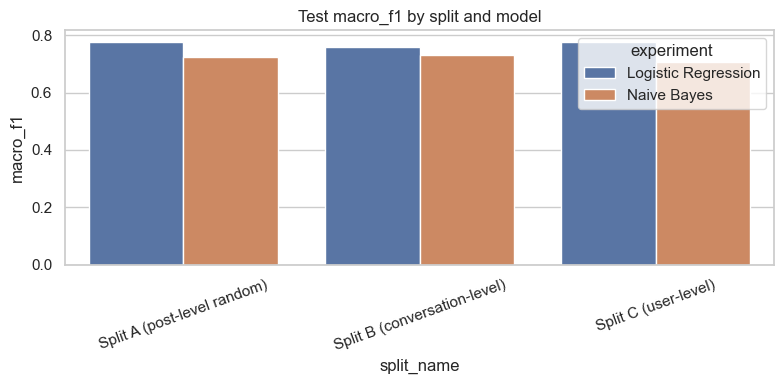

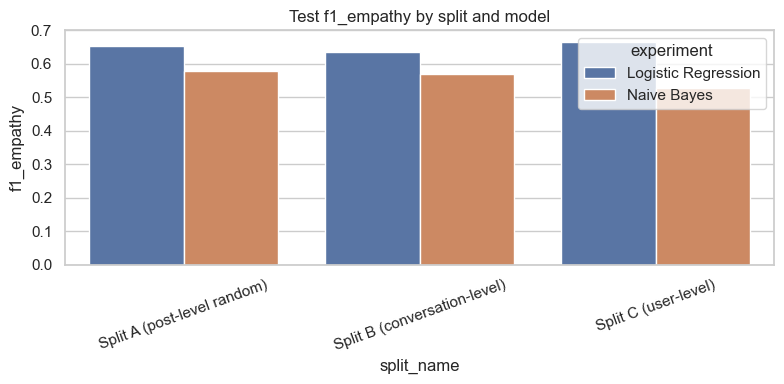

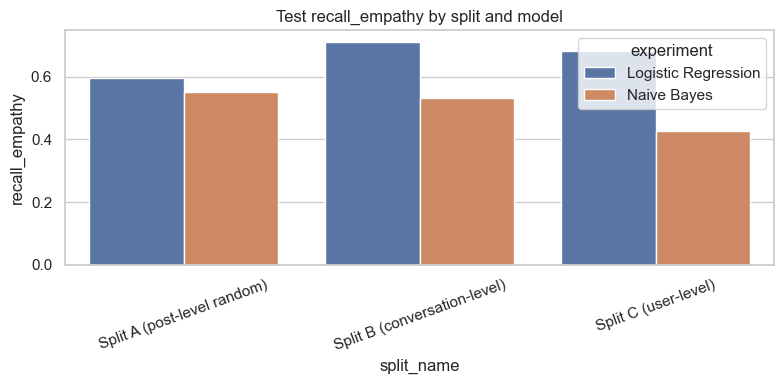

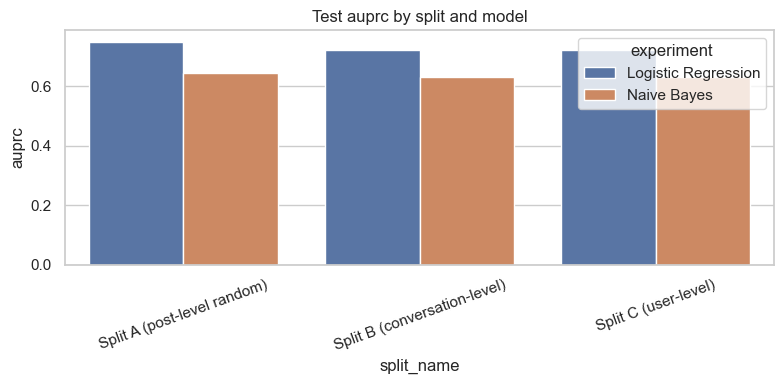

In [17]:
for metric in ["macro_f1", "f1_empathy", "recall_empathy", "auprc"]:
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=test_results,
        x="split_name",
        y=metric,
        hue="experiment"
    )
    plt.title(f"Test {metric} by split and model")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 16. Select the best final model

We will focus on  Split B, choosing the best **test** model on Split B


This reflects the idea that conversation-level evaluation is the stronger estimate of real generalisation.

In [18]:
preferred_split_name = "Split B (conversation-level)" if split_B is not None else "Split A (post-level random)"
preferred_candidates = test_results[test_results["split_name"] == preferred_split_name].copy()

if preferred_candidates.empty:
    preferred_candidates = test_results.copy()

best_final_row = preferred_candidates.sort_values(
    ["macro_f1", "f1_empathy", "auprc"],
    ascending=False
).iloc[0]

best_final_row

experiment                       Logistic Regression
split                                           test
threshold                                       0.51
accuracy                                     0.82433
macro_f1                                    0.760514
precision_empathy                           0.575486
recall_empathy                              0.712963
f1_empathy                                   0.63689
precision_no_empathy                        0.915301
recall_no_empathy                           0.855028
f1_no_empathy                               0.884138
auprc                                       0.722632
split_name              Split B (conversation-level)
C                                                1.0
nb_variant                                       NaN
alpha                                            NaN
Name: 5, dtype: object

## 17. Retrieve the artefacts for the best final model
This cell retrieves:
- the trained model
- the vectorizer
- the selected threshold
- the train/validation/test subsets for that split

In [19]:
best_split_name = best_final_row["split_name"]
best_model_name = best_final_row["experiment"]

best_bundle = all_artifacts[best_split_name]
best_vectorizer = best_bundle["vectorizer"]
best_subsets = best_bundle["data_subsets"]

if best_model_name == "Logistic Regression":
    best_model_artifacts = best_bundle["lr"]
else:
    best_model_artifacts = best_bundle["nb"]

best_model = best_model_artifacts["model"]
best_threshold = best_model_artifacts["threshold"]

print("Best split:", best_split_name)
print("Best model:", best_model_name)
print("Best threshold:", best_threshold)
print("Best parameters:", best_model_artifacts["params"])

Best split: Split B (conversation-level)
Best model: Logistic Regression
Best threshold: 0.51
Best parameters: {'C': 1.0}


## 18. Inspect the best final model
We now visualise:
- confusion matrix
- precision-recall curve
- top weighted features (for Logistic Regression)

This makes the final result more interpretable.

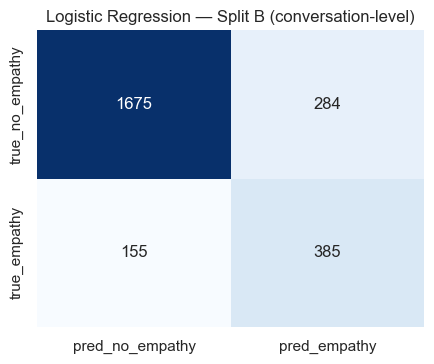

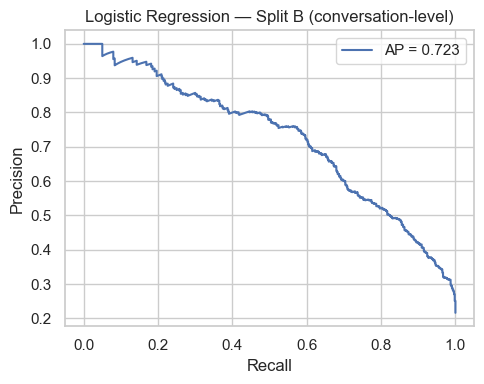

In [20]:
y_test_best = best_subsets["test"][label_col].values
y_test_pred_best = best_model_artifacts["test_pred"]
y_test_score_best = best_model_artifacts["test_score"]

plot_confusion_matrix(y_test_best, y_test_pred_best, f"{best_model_name} — {best_split_name}")
plot_pr_curve(y_test_best, y_test_score_best, f"{best_model_name} — {best_split_name}")

## 21. Error analysis sample

This section extracts examples from the **best final model**:
- false positives
- false negatives
- uncertain cases near the threshold

These examples can be used in the report to discuss annotation ambiguity and model behaviour.

In [22]:
def collect_error_examples(subset_df, y_true, y_pred, y_score, threshold, top_n=20):
    out = subset_df.copy()
    out["y_true"] = y_true
    out["y_pred"] = y_pred
    out["score_empathy"] = y_score
    out["distance_to_threshold"] = np.abs(out["score_empathy"] - threshold)

    fps = out[(out["y_true"] == 0) & (out["y_pred"] == 1)].sort_values("score_empathy", ascending=False).head(top_n)
    fns = out[(out["y_true"] == 1) & (out["y_pred"] == 0)].sort_values("score_empathy", ascending=True).head(top_n)
    uncertain = out.sort_values("distance_to_threshold", ascending=True).head(top_n)

    cols = [text_col, "text_final", "y_true", "y_pred", "score_empathy"]
    cols = [c for c in cols if c in out.columns]

    return fps[cols], fns[cols], uncertain[cols]

fps_df, fns_df, uncertain_df = collect_error_examples(
    best_subsets["test"],
    y_test_best,
    y_test_pred_best,
    y_test_score_best,
    best_threshold,
    top_n=20
)

print("False positives")
display(fps_df)

print("False negatives")
display(fns_df)

print("Uncertain cases (closest to threshold)")
display(uncertain_df)

False positives


,text,text_final,y_true,y_pred,score_empathy
5928,This sounds like me to a T. I avoid mirrors li...,this sound like me to a t i avoid mirror like ...,0,1,0.966780
8509,Deep stuff. Well since were on the subject. ...,deep stuff well since were on the subject arou...,0,1,0.947263
4715,More than half of my life has been spent strug...,more than half of my life ha been spent strugg...,0,1,0.946112
7579,Nobody I know can relate to my skin issues eit...,nobody i know can relate to my skin issue eith...,0,1,0.931765
4500,Sounds like you understand yourself pretty w...,sound like you understand yourself pretty well...,0,1,0.927175
4380,Acne is a horrible cruel disease - but it does...,acne is a horrible cruel disease but it doe ma...,0,1,0.914816
3069,I'm sure lots of people wth acne feel the same...,i m sure lot of people wth acne feel the same ...,0,1,0.911121
2138,"Hi everyone, I am 18 years old boy. I want you...",hi everyone i am year old boy i want your opin...,0,1,0.909826
1466,Hi there. Show your mom your post and tell her...,hi there show your mom your post and tell her ...,0,1,0.908454
11069,Aww don't feel that way. I know beautiful peop...,aww don t feel that way i know beautiful peopl...,0,1,0.907635


False negatives


,text,text_final,y_true,y_pred,score_empathy
1498,"Yeah, i also don't like making eye contact rea...",yeah i also don t like making eye contact real...,1,0,0.088315
8079,I am a picker too. Had no problems during hi...,i am a picker too had no problem during high s...,1,0,0.113596
11653,Me too The days I'm acne free I live them like...,me too the day i m acne free i live them like ...,1,0,0.124553
10043,I get where youre coming from. I hate being ne...,i get where youre coming from i hate being nex...,1,0,0.132692
8692,"Ha, same here! My friend would be like ""I'm br...",ha same here my friend would be like i m break...,1,0,0.141119
5043,Acne spots just draw attention to them. What d...,acne spot just draw attention to them what do ...,1,0,0.149483
8512,you mean like a merciful death? i can underst...,you mean like a merciful death i can understan...,1,0,0.153634
1069,This was exactly my life in 2004/05 - tough ti...,this wa exactly my life in tough time if i nee...,1,0,0.169942
6712,"I feel you! I'm 17 now, and use to have really...",i feel you i m now and use to have really nice...,1,0,0.170130
8551,"Good Post! I can really relate to it, I'd love...",good post i can really relate to it i d love t...,1,0,0.173289


Uncertain cases (closest to threshold)


,text,text_final,y_true,y_pred,score_empathy
3231,Thanks. Sorry to hear your going through a sim...,thanks sorry to hear your going through a simi...,1,1,0.510625
7749,"Sxdness, when my skin first started to break o...",sxdness when my skin first started to break ou...,0,0,0.508965
10298,"Hi everyone, i wanted to keep updating with my...",hi everyone i wanted to keep updating with my ...,0,0,0.508678
1455,I don't believe in the sweat thing or being ex...,i don t believe in the sweat thing or being ex...,0,0,0.508533
6599,Have you tried Accutane? I know you said you'v...,have you tried accutane i know you said you ve...,0,1,0.511814
10262,I've had the same feelings and decided enough'...,i ve had the same feeling and decided enough s...,1,0,0.508178
7362,"Well, when you don't have a choice it makes it...",well when you don t have a choice it make it i...,0,0,0.508144
1887,For a long time I resisted the idea of going o...,for a long time i resisted the idea of going o...,0,1,0.512438
8220,"Eight years, did your read that? I said eight ...",eight year did your read that i said eight god...,0,0,0.507380
3481,"Hey, I understand your sentiment...but that re...",hey i understand your sentiment but that reall...,1,0,0.507368


## 22. Final summary table


In [23]:
summary_cols = [
    "split_name", "experiment", "accuracy", "macro_f1",
    "precision_empathy", "recall_empathy", "f1_empathy",
    "auprc", "threshold"
]
summary_cols = [c for c in summary_cols if c in test_results.columns]

final_summary_table = test_results[summary_cols].sort_values(
    ["split_name", "macro_f1", "f1_empathy"], ascending=[True, False, False]
).reset_index(drop=True)

final_summary_table

,split_name,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,auprc,threshold
0,Split A (post-level random),Logistic Regression,0.846500,0.777567,0.725410,0.594958,0.653740,0.750160,0.63
1,Split A (post-level random),Naive Bayes,0.803111,0.724665,0.604779,0.552941,0.577700,0.644687,0.60
2,Split B (conversation-level),Logistic Regression,0.824330,0.760514,0.575486,0.712963,0.636890,0.722632,0.51
3,Split B (conversation-level),Naive Bayes,0.826731,0.730758,0.614561,0.531481,0.570010,0.631365,0.61
4,Split C (user-level),Logistic Regression,0.834112,0.778123,0.651376,0.682692,0.666667,0.722147,0.55
5,Split C (user-level),Naive Bayes,0.815421,0.707205,0.695925,0.426923,0.529201,0.632117,0.64


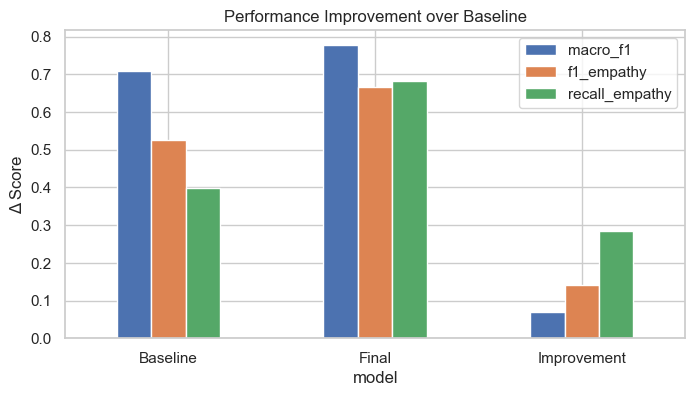

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load baseline
baseline_df = pd.read_csv("results/baseline_results.csv")

# Your final results (assuming already in df_final)
# If needed:
df_final = final_summary_table

# =========================
# Select best models only
# =========================

baseline_best = baseline_df.loc[baseline_df["macro_f1"].idxmax()]
final_best = df_final.loc[df_final["macro_f1"].idxmax()]

comparison = pd.DataFrame([
    {
        "model": "Baseline",
        "macro_f1": baseline_best["macro_f1"],
        "f1_empathy": baseline_best["f1_empathy"],
        "recall_empathy": baseline_best["recall_empathy"]
    },
    {
        "model": "Final",
        "macro_f1": final_best["macro_f1"],
        "f1_empathy": final_best["f1_empathy"],
        "recall_empathy": final_best["recall_empathy"]
    }
])

comparison = comparison.set_index("model")
improvement = comparison.copy()
improvement.loc["Improvement"] = comparison.loc["Final"] - comparison.loc["Baseline"]

improvement.plot(kind="bar")
plt.title("Performance Improvement over Baseline")
plt.ylabel("Δ Score")
plt.xticks(rotation=0)
plt.show()



# Conclusions


    The proposed improvements resulted in a substantial increase in performance, particularly for the minority empathy class. While macro-F1 improved moderately (+0.07), the recall for empathy increased significantly (+0.28), demonstrating that the model is now much more effective at identifying empathetic content. This confirms that addressing class imbalance and optimizing the decision threshold are critical for this task.